In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
# Physical constants
rho_base = 1.225    # air density (kg/m^3)
Cd_base = 0.29      # drag coefficient (typical passenger car)
A_base = 2.2        # frontal area (m^2)
Cr_base = 0.015     # rolling resistance coefficient
m_base = 1500       # vehicle mass (kg)
g_base = 9.81       # gravity (m/s^2)

# Speed range
v_kmh = np.linspace(10, 160, 200)
v = v_kmh / 3.6   # convert to m/s

# Forces
F_drag = 0.5 * rho_base * Cd_base * A_base * v**2
F_roll = Cr_base * m_base * g_base
F_total = F_drag + F_roll

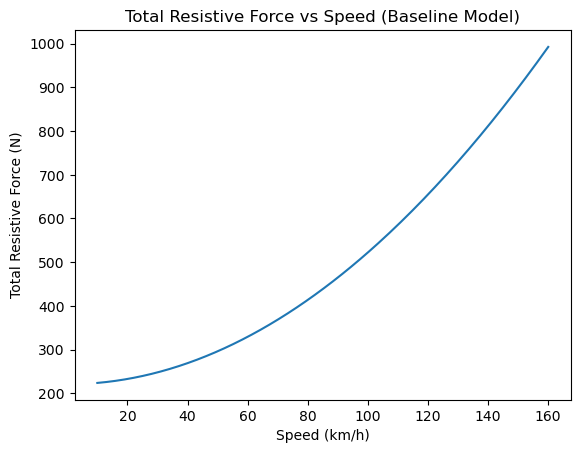

In [16]:
plt.plot(v_kmh, F_total)
plt.xlabel("Speed (km/h)")
plt.ylabel("Total Resistive Force (N)")
plt.title("Total Resistive Force vs Speed (Baseline Model)")
plt.show()

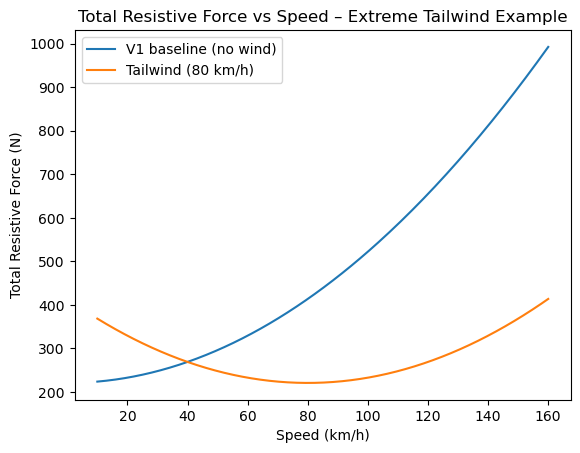

In [4]:
v_wind_kmh = 80

plt.plot(v_kmh, F_total, label="V1 baseline (no wind)")

v_wind = v_wind_kmh / 3.6
v_rel = v - v_wind
F_drag = 0.5 * rho_base * Cd_base * A_base * v_rel ** 2
F_total_wind = F_drag + F_roll

plt.plot(v_kmh, F_total_wind, label="Tailwind (80 km/h)")

plt.xlabel("Speed (km/h)")
plt.ylabel("Total Resistive Force (N)")
plt.title("Total Resistive Force vs Speed – Extreme Tailwind Example")
plt.legend()
plt.show()

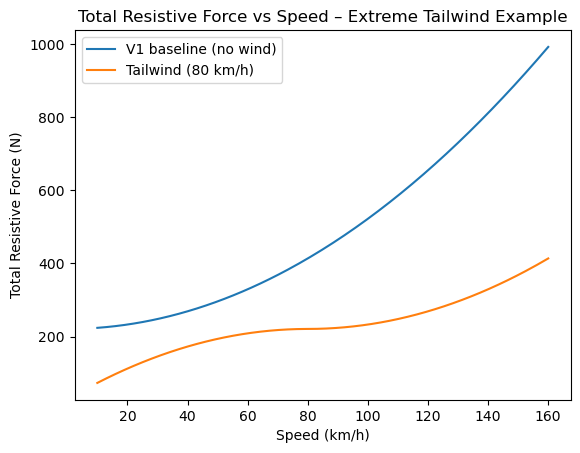

In [5]:
v_wind_kmh = 80

plt.plot(v_kmh, F_total, label="V1 baseline (no wind)")

F_drag = 0.5 * rho_base * Cd_base * A_base * v_rel * abs(v_rel)
F_total_wind = F_drag + F_roll

plt.plot(v_kmh, F_total_wind, label="Tailwind (80 km/h)")

plt.xlabel("Speed (km/h)")
plt.ylabel("Total Resistive Force (N)")
plt.title("Total Resistive Force vs Speed – Extreme Tailwind Example")
plt.legend()
plt.show()

In [6]:
def calculate_total_force(v_kmh, v_wind_kmh=0, mass=m_base, rho=rho_base, Cd=Cd_base, area=A_base, Cr=Cr_base, g=g_base):
    v_ms = v_kmh / 3.6   # convert to m/s
    v_wind_ms = v_wind_kmh / 3.6
    v_rel = v_ms - v_wind_ms
    f_drag = 0.5 * rho_base * Cd * area * v_rel * np.abs(v_rel)
    f_roll = Cr * mass * g

    f_total = f_drag + f_roll
    return f_total

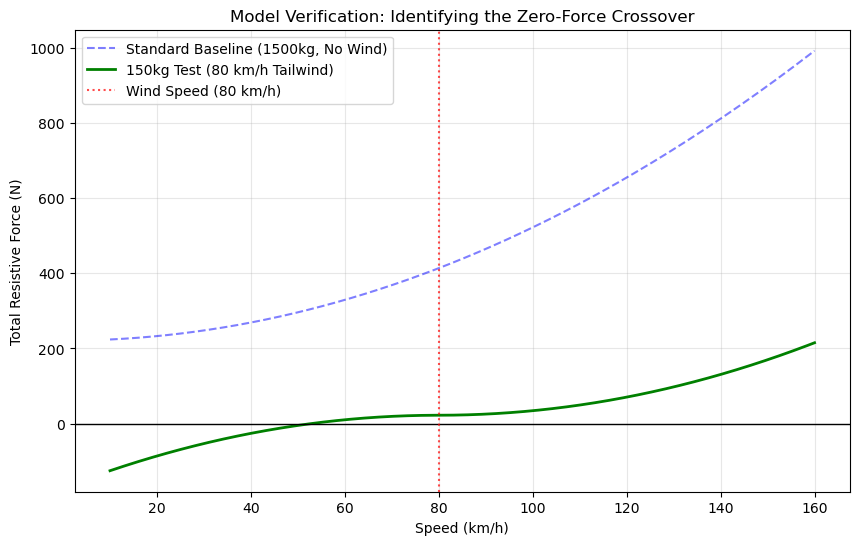

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(v_kmh, calculate_total_force(v_kmh), label="Standard Baseline (1500kg, No Wind)", color="blue", linestyle="--", alpha=0.5)
F_verification = calculate_total_force(v_kmh, v_wind_kmh=80, mass=150)
plt.plot(v_kmh, F_verification, label="150kg Test (80 km/h Tailwind)", color="green", linewidth=2)

plt.axhline(0, color='black', linewidth=1)
plt.axvline(80, color='red', linestyle=':', alpha=0.7, label="Wind Speed (80 km/h)")
plt.xlabel("Speed (km/h)")
plt.ylabel("Total Resistive Force (N)")
plt.title("Model Verification: Identifying the Zero-Force Crossover")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

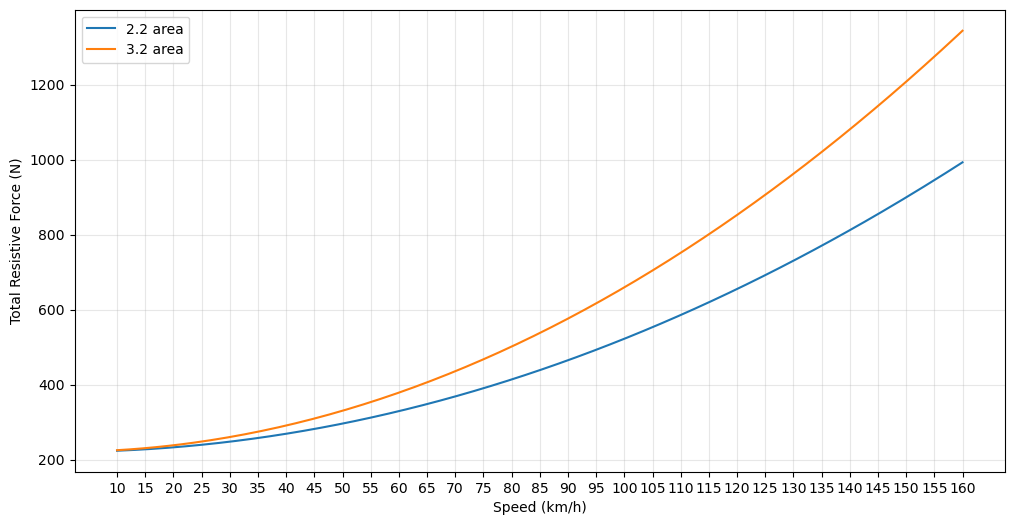

In [18]:
F_large_area = calculate_total_force(v_kmh, area=3.2)
v_kmh
plt.figure(figsize=(12, 6))
plt.xticks(np.arange(10, 161, 5))
plt.grid(True, alpha=0.3)
plt.plot(v_kmh, calculate_total_force(v_kmh), label="2.2 area")
plt.plot(v_kmh, F_large_area, label="3.2 area")
plt.xlabel("Speed (km/h)")
plt.ylabel("Total Resistive Force (N)")
plt.legend()
plt.show()

In [21]:
def plot_results(v_array, scenarios, title=None):
    plt.figure(figsize=(12, 6))

    for s in scenarios:
        plt.plot(v_array, s['data'], label=s['label'])
    
    plt.xticks(np.arange(min(v_array), max(v_array)+1, 5))
    plt.grid(True, alpha=0.3)
    plt.xlabel("Speed (km/h)")
    plt.ylabel("Total Resistive Force (N)")
    plt.title(title)
    plt.legend()
    plt.show()

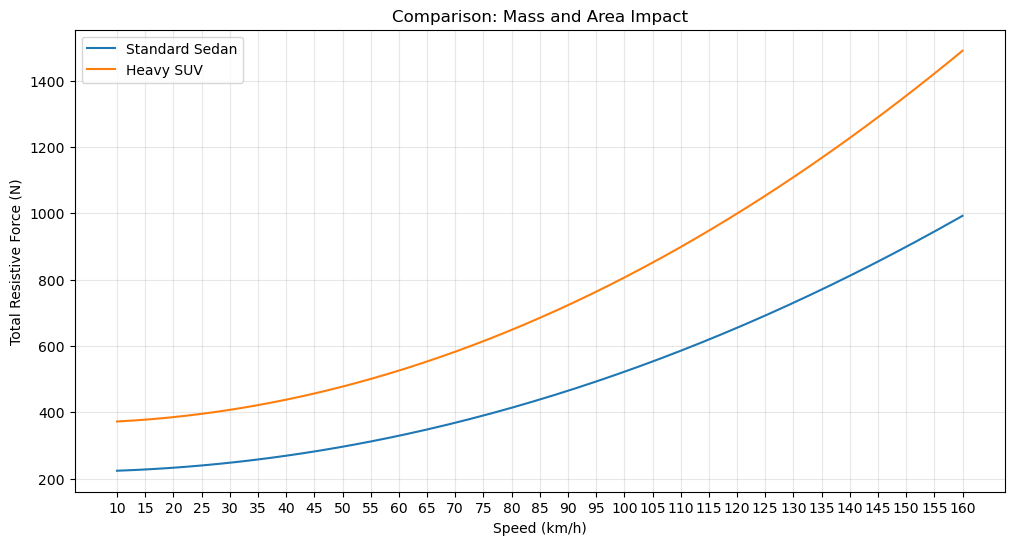

In [22]:
s1 = {'label': "Standard Sedan", 'data': calculate_total_force(v_kmh)}
s2 = {'label': "Heavy SUV", 'data': calculate_total_force(v_kmh, mass=2500, area=3.2)}
plot_results(v_kmh, [s1, s2], title="Comparison: Mass and Area Impact")